In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os

os.chdir('C:\\Dania\\2024\\Australian Election')

# Voting data required 2016->2021 Correspondence/Concordance : shapefile_path = 'SA1_2021_AUST_GDA2020.shp'
shapefile_path = 'SA1_2016_AUST.shp'
gdf_full = gpd.read_file(shapefile_path)

# GDF Format

In [3]:
# 
print(gdf_full.columns)

gdf = gdf_full.drop(gdf_full.index[-1])
gdf['centroid'] = gdf.geometry.centroid
gdf['Lat'] = gdf.centroid.y
gdf['Long'] = gdf.centroid.x

print(gdf)



Index(['SA1_MAIN16', 'SA1_7DIG16', 'SA2_MAIN16', 'SA2_5DIG16', 'SA2_NAME16',
       'SA3_CODE16', 'SA3_NAME16', 'SA4_CODE16', 'SA4_NAME16', 'GCC_CODE16',
       'GCC_NAME16', 'STE_CODE16', 'STE_NAME16', 'AREASQKM16', 'geometry'],
      dtype='object')


C:\Users\Danie\AppData\Local\Temp\ipykernel_3808\3761942500.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
C:\Users\Danie\AppData\Local\Temp\ipykernel_3808\3761942500.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['Lat'] = gdf.centroid.y
C:\Users\Danie\AppData\Local\Temp\ipykernel_3808\3761942500.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['Long'] = gdf.centroid.x


        SA1_MAIN16 SA1_7DIG16 SA2_MAIN16 SA2_5DIG16  \
0      10102100701    1100701  101021007      11007   
1      10102100702    1100702  101021007      11007   
2      10102100703    1100703  101021007      11007   
3      10102100704    1100704  101021007      11007   
4      10102100705    1100705  101021007      11007   
...            ...        ...        ...        ...   
57517  90104100405    9100405  901041004      91004   
57518  90104100406    9100406  901041004      91004   
57519  90104100407    9100407  901041004      91004   
57520  90104100408    9100408  901041004      91004   
57521  99797979993    9979993  997979799      99799   

                                 SA2_NAME16 SA3_CODE16  \
0                                 Braidwood      10102   
1                                 Braidwood      10102   
2                                 Braidwood      10102   
3                                 Braidwood      10102   
4                                 Braidwood      

# Convert to Australian Albers projection (not used currently)

In [4]:
# Convert to Australian Albers projection for more accurate centroids/distances - will compare if this speeds things up!!!
gdf_Aust = gdf.to_crs("EPSG:3577")
print(gdf_Aust)

print(gdf_Aust.columns)
gdf_Aust['centroid'] = gdf_Aust['geometry'].centroid
gdf_Aust['Lat'] = gdf_Aust.centroid.y
gdf_Aust['Long'] = gdf_Aust.centroid.x
print(gdf_Aust[['SA1_7DIG16','centroid','Lat','Long']])




        SA1_MAIN16 SA1_7DIG16 SA2_MAIN16 SA2_5DIG16  \
0      10102100701    1100701  101021007      11007   
1      10102100702    1100702  101021007      11007   
2      10102100703    1100703  101021007      11007   
3      10102100704    1100704  101021007      11007   
4      10102100705    1100705  101021007      11007   
...            ...        ...        ...        ...   
57517  90104100405    9100405  901041004      91004   
57518  90104100406    9100406  901041004      91004   
57519  90104100407    9100407  901041004      91004   
57520  90104100408    9100408  901041004      91004   
57521  99797979993    9979993  997979799      99799   

                                 SA2_NAME16 SA3_CODE16  \
0                                 Braidwood      10102   
1                                 Braidwood      10102   
2                                 Braidwood      10102   
3                                 Braidwood      10102   
4                                 Braidwood      

# df with SA1 information

In [5]:
# create df with 7-digit SA1s and their lat and long values
SA1_centroids_7dig = pd.concat([gdf['SA1_7DIG16'],gdf['Lat'],gdf['Long']], axis=1)
SA1_centroids_7dig['SA1_7DIG16'] = SA1_centroids_7dig['SA1_7DIG16'].astype(int)
print(SA1_centroids_7dig.loc[SA1_centroids_7dig["SA1_7DIG16"] == 2117417,])


### 2021 version, in case ever needed:
#SA1_centroids_11dig = pd.concat([gdf['SA1_CODE21'],gdf['Lat'],gdf['Long']], axis=1)
#SA1_centroids_7dig = SA1_centroids_11dig
#SA1_centroids_7dig['SA1_CODE21'] = SA1_centroids_7dig['SA1_CODE21'].astype(str).str[:1] + SA1_centroids_7dig['SA1_CODE21'].astype(str).str[5:]
#SA1_centroids_7dig['SA1_CODE21'] = SA1_centroids_7dig['SA1_CODE21'].astype(int)
#print(SA1_centroids_7dig.loc[SA1_centroids_7dig["SA1_CODE21"] == 2117417,])

       SA1_7DIG16        Lat        Long
23324     2117417 -37.913956  145.026328


# df for PB,PPVC,SA1 votes by PP data

In [6]:
# Create dataframes for PB,PPVC data, SA1 votes by polling place

DEGREE_TO_KM = 111.319

PB_data_full = pd.read_csv("PollingBoothData2022.csv", index_col=None)
PB_data_full['DivName'] = PB_data_full['DivName'].str.strip()
PB_data = PB_data_full[["DivName","PPId","Lat","Long","OrdVoteEst","DecVoteEst"]]
PB_data.set_index('PPId', inplace=True)
PB_data.index.rename('pp_id', inplace=True)
PB_data.insert(0,'Booth_type',"PB")
#print(PB_data)


PPVC_data_full = pd.read_csv("PPVCData2022.csv")
PPVC_data = PPVC_data_full[["PPId","DivName","Lat","Long","OrdVoteEst","DecVoteEst"]]
# Issue resolved: encountering issue - I want to combine all the rows with identical entries, but am wary that there might be PPVC that are valid for the same division. A simple solution would be to introduce the index column as an ordinary column again. Why not?
PPVC_data = PPVC_data.groupby(["PPId","DivName","Lat","Long","OrdVoteEst","DecVoteEst"]).first().reset_index()
PPVC_data.set_index('PPId', inplace=True)
PPVC_data.index.rename('pp_id', inplace=True)
PPVC_data.insert(0,'Booth_type',"PPVC")


PB_combined = pd.concat([PB_data,PPVC_data], axis=0)
#print(PB_combined)


SA1_By_PB_full = pd.read_csv("2022VotesBySA1.csv")
# checked that all EAV COVID19 Booths that are not on the polling booths data are between 108484 and 108676. Only booths of concern are 108689 in Durack and 108711 in Page (Lismore). My guess is they were added due to natural disaster emergencies, hence similar to COVID Mobile Voting. As they also neither appear on the PPVC nor Polling Booths csvs, they will be given an index of 0 alongside all the absent, postal etc votes.
#list1 = sorted(SA1_By_PB_full.loc[SA1_By_PB_full['pp_nm'].astype(str).str.startswith('EAV COVID19'),"pp_id"].unique())
#list2 = sorted(SA1_By_PB_full["pp_id"].unique())
#not_in_list2 = [x for x in list2 if x not in list1]

SA1_By_PB = SA1_By_PB_full[["div_nm","ccd_id","pp_id","votes"]]
SA1_By_PB = SA1_By_PB.rename(columns={'ccd_id': 'SA1_7DIG16'})

In [16]:
# make csv files of extracted data - saves time after computer reboot!

SA1_By_PB.to_csv("SA1_By_PB.csv", index=False)
PB_combined.to_csv("PB_combined.csv")
PB_data.to_csv("PB_data.csv")
PPVC_data.to_csv("PPVC_data.csv")


# Extract list of SA1s for specified electorate

In [13]:
def SA1_of_electorate_extractor(electorate):
    ### electorate must be string name of one of existing 150/151 electorates.

    electorate_SA1s = SA1_By_PB.loc[SA1_By_PB["div_nm"]==electorate,"SA1_7DIG16"].unique()
    
    return electorate_SA1s

# specifically for Wannon and Goldstein
len(SA1_of_electorate_extractor("Goldstein"))
Wannon_SA1s = SA1_of_electorate_extractor("Wannon")
len(Wannon_SA1s)

430

# Goldstein-specific - extract all SA1s

In [134]:
# Combine SA1 vote data with long,lat coordinates - maybe not necessary, as they work better as two separate tables?

#SA1_By_PB_Centroids = SA1_By_PB.merge(SA1_centroids_7dig, on = "SA1_7DIG16", how = "left")


print(len(sorted(SA1_By_PB["SA1_7DIG16"].unique())))
Goldstein_SA1s = SA1_By_PB.loc[SA1_By_PB["div_nm"]=="Goldstein","SA1_7DIG16"].unique()
# Fix later - for universality, can do the .loc Goldstein later when using the [[Lat]] and [[Long]] columns
Goldstein_PB = PB_combined.loc[PB_combined["DivName"]=="Goldstein",]
Vote_Distances_Goldstein_Dict = {}
#print(Goldstein_SA1s)

# All SA1s accounted for! - no need to re-implement

#sum = 0
#for SA1 in SA1_By_PB.loc[:,"SA1_7DIG16"].unique():
#    if SA1 not in SA1_centroids_7dig.loc[:,"SA1_7DIG16"].values and not str(SA1).endswith("9999"): # Need to ignore those that end with 9999 - sum to ~20 votes only
#        print(SA1)
#        sum += 1
#print(sum)

56302


# Create Vote Distances to PP df and plot

In [135]:
i = 0
for SA1 in Goldstein_SA1s:

    # Calculate centroid coordinates of the SA1
    SA1_Lat = SA1_centroids_7dig.loc[SA1_centroids_7dig["SA1_7DIG16"] == SA1,"Lat"].iloc[0]
    SA1_Long = SA1_centroids_7dig.loc[SA1_centroids_7dig["SA1_7DIG16"] == SA1,"Long"].iloc[0]

    # Create df of distance from SA1 centroid to each polling booth
    Golstein_Distances_Locations = pd.DataFrame({
    "Distance": DEGREE_TO_KM*np.sqrt((Goldstein_PB[["Lat"]].iloc[:, 0]- SA1_Lat)**2 + (Goldstein_PB[["Long"]].iloc[:, 0]- SA1_Long)**2),
    "Booth_type": Goldstein_PB["Booth_type"]})

    Other_votes = pd.DataFrame({'Distance': None, "Booth_type": "Other"}, index = [0])
    Golstein_Distances = pd.concat([Golstein_Distances_Locations,Other_votes])
    Golstein_Distances.index.name = Golstein_Distances_Locations.index.name

    Goldstein_PB_SA1 = SA1_By_PB.loc[SA1_By_PB["SA1_7DIG16"]==SA1,]
    Vote_Distances_Goldstein_SA1 = pd.merge(Golstein_Distances, Goldstein_PB_SA1[["pp_id","votes"]], on='pp_id', how='left')
    Vote_Distances_Goldstein_SA1.set_index('pp_id', inplace=True)
    Vote_Distances_Goldstein_SA1.loc[Vote_Distances_Goldstein_SA1["votes"].isna(),"votes"] = 0

    Vote_Distances_Goldstein_Dict[SA1] = Vote_Distances_Goldstein_SA1

print(Vote_Distances_Goldstein_Dict)

{2116801:          Distance Booth_type  votes
pp_id                              
4133     2.326099         PB    0.0
83811    0.954928         PB    0.0
4136     0.705788         PB    0.0
3852     5.584629         PB    0.0
31762    6.164012         PB    0.0
64688    4.762420         PB    0.0
3853     5.766871         PB    0.0
4138     0.962701         PB    1.0
4139     1.017927         PB    0.0
3854     7.315717         PB    0.0
3855     6.625546         PB    0.0
3857     5.812801         PB    0.0
3873     7.832662         PB    0.0
3866     8.757615         PB    0.0
3897     8.862917         PB    0.0
3860     8.809531         PB    0.0
3864     9.469643         PB    0.0
3896     8.484634         PB    0.0
3859     8.674955         PB    0.0
4145     2.816386         PB    0.0
63669    9.778971         PB    0.0
3865     9.696879         PB    0.0
3867     5.163467         PB    0.0
3868     4.485163         PB    0.0
3874     4.566275         PB    0.0
3869     2.809681 

Done: 2116801
Done: 2116802
Done: 2116803
Done: 2116804
Done: 2116805
Done: 2116806
Done: 2116807
Done: 2116808
Done: 2116809
Done: 2116810
Done: 2116811
Done: 2116812
Done: 2116813
Done: 2116814
Done: 2116815
Done: 2116816
Done: 2116817
Done: 2116818
Done: 2116819
Done: 2116820
Done: 2116821
Done: 2116822
Done: 2116823
Done: 2116824
Done: 2116825
Done: 2116826
Done: 2116827
Done: 2116828
Done: 2116829
Done: 2116830
Done: 2116831
Done: 2116832
Done: 2116901
Done: 2116902
Done: 2116903
Done: 2116904
Done: 2116905
Done: 2116906
Done: 2116907
Done: 2116908
Done: 2116909
Done: 2116910
Done: 2116911
Done: 2116912
Done: 2116913
Done: 2116914
Done: 2116915
Done: 2116916
Done: 2116917
Done: 2116918
Done: 2116919
Done: 2116920
Done: 2116921
Done: 2116922
Done: 2116923
Done: 2116924
Done: 2116925
Done: 2116926
Done: 2116927
Done: 2116928
Done: 2116929
Done: 2116930
Done: 2116931
Done: 2116932
Done: 2116933
Done: 2116934
Done: 2116935
Done: 2116936
Done: 2116937
Done: 2116938
Done: 2116939
Done: 

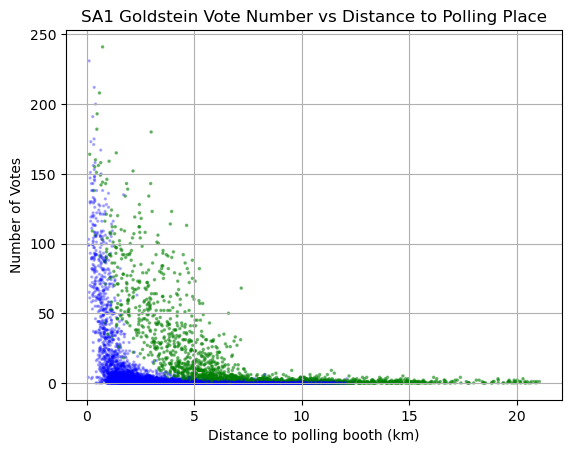

In [144]:
# plotting it all for Goldstein:
from matplotlib import pyplot as plt

for SA1 in Goldstein_SA1s:
    condition = Vote_Distances_Goldstein_Dict[SA1]['Booth_type'] == "PB"

    plt.scatter(Vote_Distances_Goldstein_Dict[SA1]['Distance'][condition], Vote_Distances_Goldstein_Dict[SA1]['votes'][condition], marker='o', linestyle = '', color = 'blue',label="PB", s=2, alpha=0.25)
    plt.scatter(Vote_Distances_Goldstein_Dict[SA1]['Distance'][~condition], Vote_Distances_Goldstein_Dict[SA1]['votes'][~condition], marker='o', linestyle = '', color = 'green',label="PPVC", s=2.5, alpha=0.45)
    print("Done:", SA1)
plt.xlabel('Distance to polling booth (km)')
plt.ylabel('Number of Votes')
plt.title('SA1 Goldstein Vote Number vs Distance to Polling Place')
plt.grid(True)
plt.show()

# Big Project #1 - Vote distribution by SA1!

Goal 1: Find how dominated each polling place is by individual SA1s \
Goal 2: Extrapolate their vote to said SA1s with mean & SD, incorporating PPVC and Postal differences/effects


In [19]:
# Find how dominated each polling place is by individual SA1 - start with Wannon

# Create dict with polling place as key and all SA1 votes there as value list - 
Wannon_PP_dict = {}
Wannon_PB = PB_combined.loc[PB_combined["DivName"]=="Wannon",]

print(Wannon_PB["pp_id"]) # how to extract index column????????

for polling_booth in Wannon_PB[["pp_id"]]:
    Wannon_PP_dict[polling_booth] = []

    for SA1 in SA1_By_PB.loc[SA1_By_PB["pp_id"] == polling_booth, "SA1_7DIG16"]:
        Wannon_PP_dict[polling_booth].append(SA1_By_PB.loc[SA1_By_PB["pp_id"] == polling_booth, "votes"])

Wannon_PB

# to do: check to make sure no polling booth corresponds to more than 1 electorate

KeyError: 'pp_id'